In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy joblib


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
os.makedirs("charts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [4]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8,5)

print("Visualization settings applied.")

Visualization settings applied.


In [5]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
display(df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.to_csv("titanic.csv", index=False)

print("Offline copy saved as titanic.csv")

Offline copy saved as titanic.csv


In [8]:
print("Dataset Shape")

print(df.shape)

Dataset Shape
(891, 15)


In [9]:
print("Dataset Information")

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [10]:
print("Statistical Summary")

display(df.describe())

Statistical Summary


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
display(
    df.describe(include="object")
)

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [12]:
print(df.dtypes)

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [13]:
missing_values = df.isnull().sum()

display(
    missing_values
)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [14]:
missing_percent = (
    df.isnull().mean() * 100
).round(2)

missing_percent = (
    missing_percent[
        missing_percent > 0
    ]
)

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_report = (
    missing_report[
        missing_report["Missing Values"] > 0
    ]
)

display(missing_report)

,Missing Values,Missing Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [15]:
missing_report.to_csv(
    "outputs/missing_value_report.csv",
    index=True
)

print(
    "Missing value report saved!"
)

Missing value report saved!


In [16]:
clean_df = df.copy()

print(
    "Working copy created."
)

Working copy created.


In [17]:
for column in missing_report.index:

    percentage = (
        missing_report.loc[
            column,
            "Missing Percentage"
        ]
    )

    print(
        f"{column} : {percentage}% missing"
    )

age : 19.87% missing
embarked : 0.22% missing
deck : 77.22% missing
embark_town : 0.22% missing


In [18]:
for column in missing_report.index:

    percentage = (
        missing_report.loc[
            column,
            "Missing Percentage"
        ]
    )

    if percentage < 5:

        strategy = "Drop rows"

    elif percentage <= 30:

        strategy = "Impute"

    else:

        strategy = "Drop column"

    print(
        f"{column} --> {strategy}"
    )

age --> Impute
embarked --> Drop rows
deck --> Drop column
embark_town --> Drop rows


In [19]:
rows_before = len(clean_df)

clean_df = clean_df.dropna(
    subset=["embarked", "embark_town"]
)

rows_after = len(clean_df)

print(
    "Rows removed:",
    rows_before - rows_after
)

Rows removed: 2


In [20]:
age_median = clean_df["age"].median()

clean_df["age"] = (
    clean_df["age"]
    .fillna(age_median)
)

print(
    "Age imputed using median."
)

Age imputed using median.


In [21]:
clean_df = clean_df.drop(
    columns=["deck"]
)

print(
    "Deck column dropped."
)

Deck column dropped.


In [22]:
remaining_missing = (
    clean_df.isnull().sum()
)

display(
    remaining_missing[
        remaining_missing > 0
    ]
)

Series([], dtype: int64)

In [23]:
print(
    "Original Shape:",
    df.shape
)

print(
    "Cleaned Shape:",
    clean_df.shape
)

Original Shape: (891, 15)
Cleaned Shape: (889, 14)


In [24]:
clean_df.to_csv(
    "outputs/cleaned_titanic.csv",
    index=False
)

print(
    "Cleaned dataset saved."
)

Cleaned dataset saved.


In [25]:
print("=" * 50)

print("MODULE 2 - PART 1 COMPLETED")

print("=" * 50)

print(
    "Original Rows:",
    len(df)
)

print(
    "Cleaned Rows:",
    len(clean_df)
)

print(
    "Columns:",
    clean_df.columns.tolist()
)

print(
    "\nRemaining Missing Values:"
)

print(
    clean_df.isnull().sum()
)

print("=" * 50)

MODULE 2 - PART 1 COMPLETED
Original Rows: 891
Cleaned Rows: 889
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Remaining Missing Values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [26]:
display(clean_df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


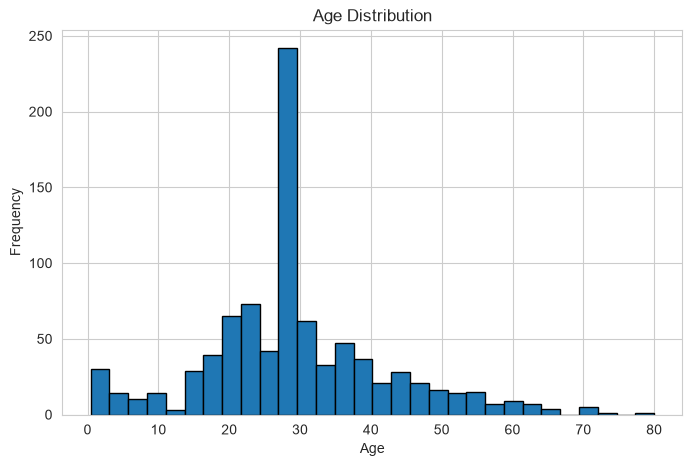

In [27]:
plt.figure(figsize=(8,5))

plt.hist(
    clean_df["age"],
    bins=30,
    edgecolor="black"
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.savefig("charts/age_histogram.png")

plt.show()

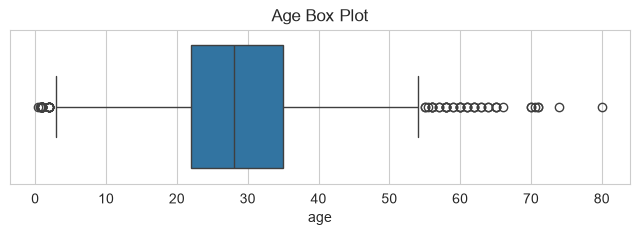

In [28]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=clean_df["age"]
)

plt.title("Age Box Plot")

plt.savefig("charts/age_boxplot.png")

plt.show()

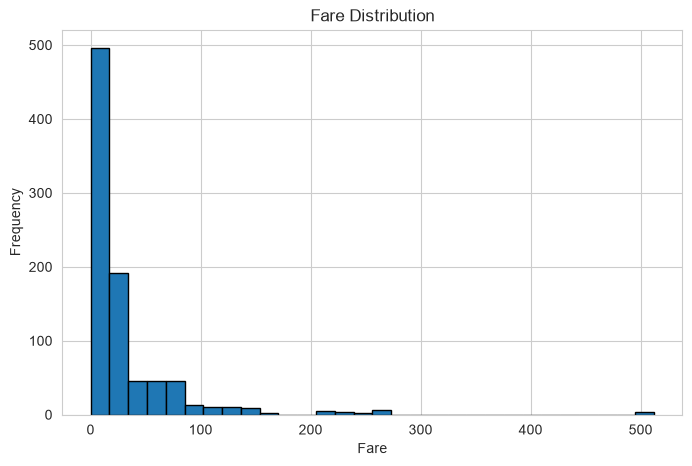

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    clean_df["fare"],
    bins=30,
    edgecolor="black"
)

plt.title("Fare Distribution")

plt.xlabel("Fare")

plt.ylabel("Frequency")

plt.savefig("charts/fare_histogram.png")

plt.show()

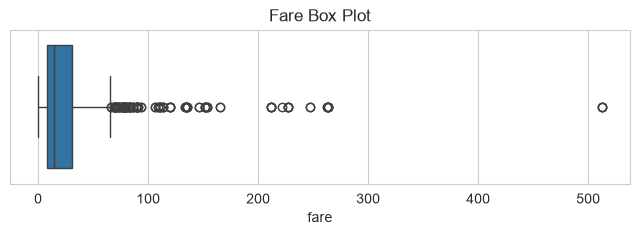

In [30]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=clean_df["fare"]
)

plt.title("Fare Box Plot")

plt.savefig("charts/fare_boxplot.png")

plt.show()

In [31]:
def count_outliers(column):

    Q1 = column.quantile(0.25)

    Q3 = column.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = column[
        (column < lower) |
        (column > upper)
    ]

    return len(outliers)

In [32]:
age_outliers = count_outliers(
    clean_df["age"]
)

print(
    "Age Outliers:",
    age_outliers
)

Age Outliers: 65


In [33]:
fare_outliers = count_outliers(
    clean_df["fare"]
)

print(
    "Fare Outliers:",
    fare_outliers
)

Fare Outliers: 114


In [34]:
fare_mean = clean_df["fare"].mean()

fare_median = clean_df["fare"].median()

fare_mode = clean_df["fare"].mode()[0]

print("Fare Mean:", fare_mean)

print("Fare Median:", fare_median)

print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


In [35]:
if fare_mean > fare_median > fare_mode:

    skew = "Right Skewed"

elif fare_mean < fare_median < fare_mode:

    skew = "Left Skewed"

else:

    skew = "Approximately Symmetric"

print("Fare Distribution:", skew)

Fare Distribution: Right Skewed


In [36]:
survival_by_sex = (
    clean_df
    .groupby("sex")["survived"]
    .mean() * 100
)

display(
    survival_by_sex
)

sex
female    74.038462
male      18.890815
Name: survived, dtype: float64

In [37]:
survival_by_class = (
    clean_df
    .groupby("pclass")["survived"]
    .mean() * 100
)

display(
    survival_by_class
)

pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64

In [38]:
survival_sex_class = (
    clean_df
    .groupby(
        ["sex","pclass"]
    )["survived"]
    .mean() * 100
)

display(
    survival_sex_class
)

sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64

In [39]:
corr_df = clean_df[
    [
        "survived",
        "pclass",
        "age",
        "sibsp",
        "parch",
        "fare"
    ]
]

In [40]:
corr_matrix = corr_df.corr()

display(
    corr_matrix
)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


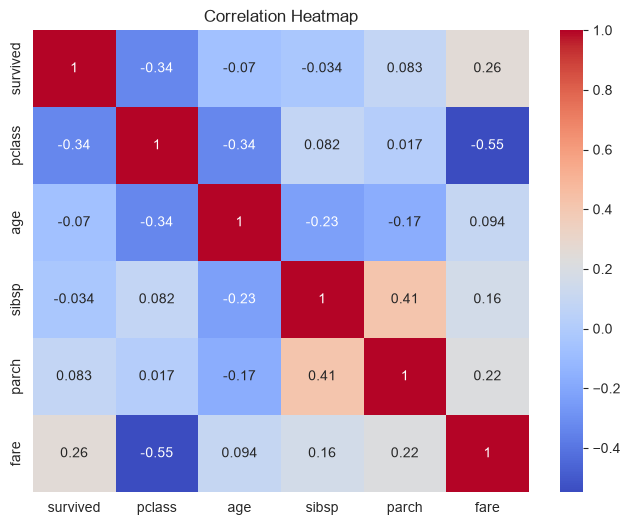

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png"
)

plt.show()

In [42]:
corr_pairs = (
    corr_matrix.abs()
    .unstack()
)

corr_pairs = corr_pairs[
    corr_pairs < 1
]

corr_pairs = (
    corr_pairs
    .sort_values(
        ascending=False
    )
)

print(
    corr_pairs.head(2)
)

pclass  fare      0.548193
fare    pclass    0.548193
dtype: float64


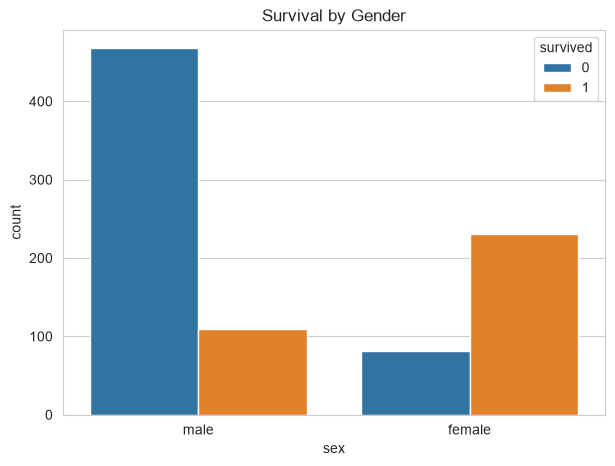

In [43]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=clean_df,
    x="sex",
    hue="survived"
)

plt.title(
    "Survival by Gender"
)

plt.savefig(
    "charts/chart1_gender_survival.png"
)

plt.show()

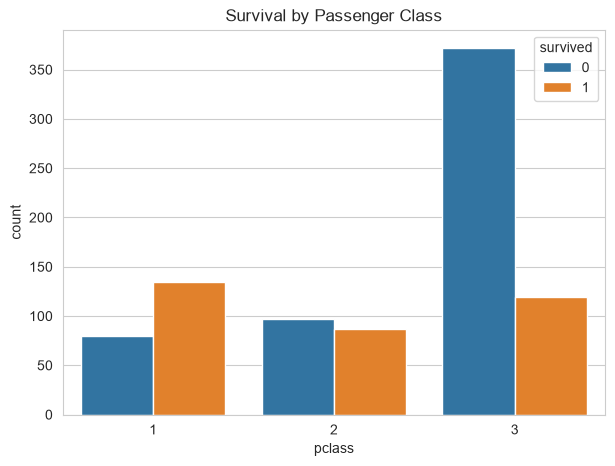

In [44]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=clean_df,
    x="pclass",
    hue="survived"
)

plt.title(
    "Survival by Passenger Class"
)

plt.savefig(
    "charts/chart2_class_survival.png"
)

plt.show()

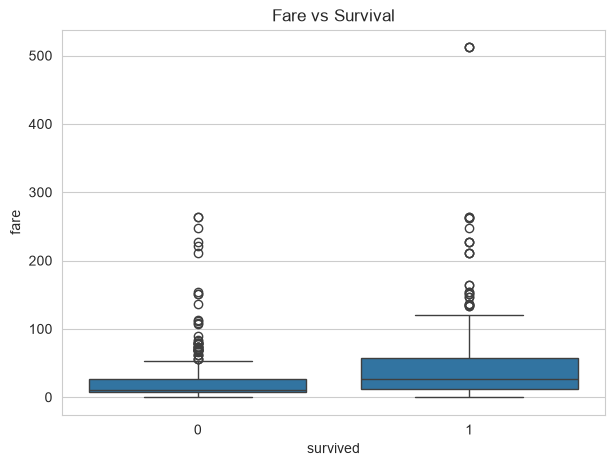

In [45]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=clean_df,
    x="survived",
    y="fare"
)

plt.title(
    "Fare vs Survival"
)

plt.savefig(
    "charts/chart3_fare_survival.png"
)

plt.show()

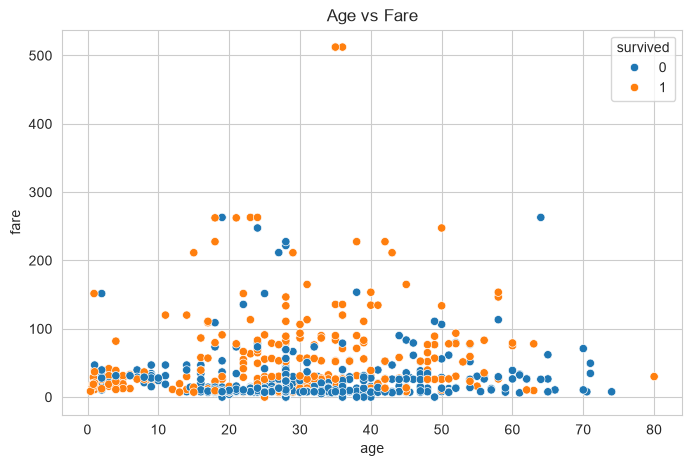

In [46]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title(
    "Age vs Fare"
)

plt.savefig(
    "charts/chart4_age_fare.png"
)

plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [48]:
scaled_df = clean_df.copy()

In [49]:
print("Before Scaling")

display(
    scaled_df[
        [
            "age",
            "fare"
        ]
    ].describe()
)

Before Scaling


,age,fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [50]:
scaled_df[
    [
        "age",
        "fare"
    ]
] = scaler.fit_transform(

    scaled_df[
        [
            "age",
            "fare"
        ]
    ]

)

In [51]:
print("After Scaling")

display(
    scaled_df[
        [
            "age",
            "fare"
        ]
    ].describe()
)

After Scaling


,age,fare
count,8.890000e+02,8.890000e+02
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00
min,-2.226536e+00,-6.462044e-01
25%,-5.636741e-01,-4.872378e-01
50%,-1.013399e-01,-3.551972e-01
75%,4.380499e-01,-2.207954e-02
max,3.905556e+00,9.668551e+00


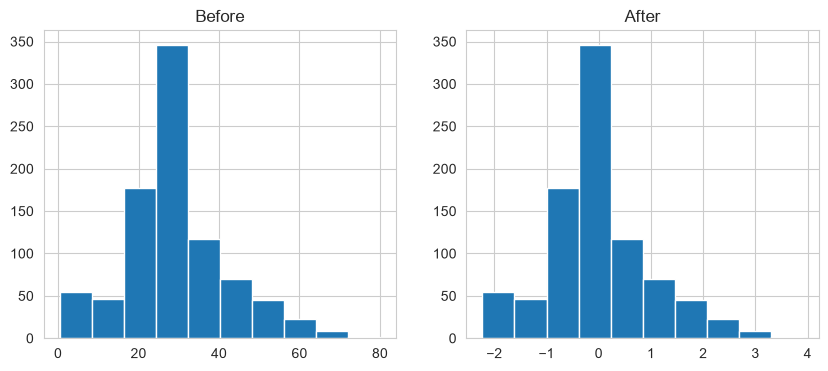

In [52]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.hist(clean_df["age"])

plt.title("Before")

plt.subplot(1,2,2)

plt.hist(scaled_df["age"])

plt.title("After")

plt.savefig(
    "charts/age_scaling.png"
)

plt.show()

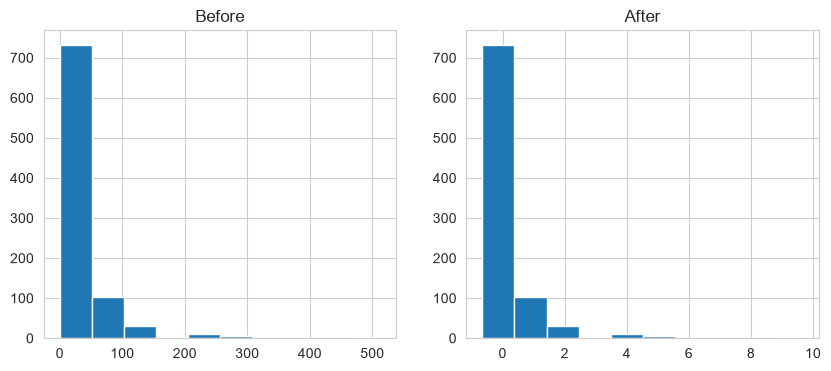

In [53]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.hist(clean_df["fare"])

plt.title("Before")

plt.subplot(1,2,2)

plt.hist(scaled_df["fare"])

plt.title("After")

plt.savefig(
    "charts/fare_scaling.png"
)

plt.show()

In [54]:
scaled_df.to_csv(
    "outputs/scaled_titanic.csv",
    index=False
)

print(
    "Scaled dataset saved."
)

Scaled dataset saved.


In [55]:
print("="*60)

print("MODULE 2 - PART 2 COMPLETED")

print("="*60)

print("Charts Generated:")

print("- Age Histogram")

print("- Age Box Plot")

print("- Fare Histogram")

print("- Fare Box Plot")

print("- Correlation Heatmap")

print("- Survival Charts")

print("- Scaling Comparison")

print()

print("Outputs Generated:")

print("- Missing Report")

print("- Cleaned Titanic")

print("- Scaled Titanic")

print("="*60)

MODULE 2 - PART 2 COMPLETED
Charts Generated:
- Age Histogram
- Age Box Plot
- Fare Histogram
- Fare Box Plot
- Correlation Heatmap
- Survival Charts
- Scaling Comparison

Outputs Generated:
- Missing Report
- Cleaned Titanic
- Scaled Titanic
